In [ ]:
import numpy as np  # standard library for math, arrays, and fast calculations
import matplotlib.pyplot as plt  # used to draw all the histograms and distributions
import matplotlib_inline  # makes sure the plots display directly inside the notebook
from matplotlib.ticker import AutoMinorLocator  # adds small sub-ticks to the axes for a cleaner look

# opens and reads Cern .root files directly in Python without needing the heavy ROOT framework
import uproot  

# for handling events where each collision has a different number of particles 
import awkward as ak  

import atlasopenmagic as atom  # gets the ATLAS Open Data URLs and metadata from the web
import requests  # handles basic internet requests to get data files
import time  # used to benchmark and measure how long the code takes to execute
import warnings  # library to manage and hide some warning messages

# the lines below hide minor math warnings (like empty bins or square roots of negatives) so they do not flood the output
warnings.filterwarnings("ignore", message="invalid value encountered in sqrt")
warnings.filterwarnings("ignore", message="overflow encountered in power")
warnings.filterwarnings("ignore", message="overflow encountered in multiply", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in subtract")

In [ ]:
atom.available_releases() # check which ATLAS open data versions are available online
atom.set_release('2025e-13tev-beta') # select the specific 13 TeV dataset version needed for this analysis

Fetching metadata for release: 2025e-13tev-beta...


Available releases:
2016e-8tev           2016 Open Data for education release of 8 TeV proton-proton collisions (https://opendata.cern.ch/record/3860).
2020e-13tev          2020 Open Data for education release of 13 TeV proton-proton collisions (https://cern.ch/2r7xt).
2024r-pp             2024 Open Data for research release for proton-proton collisions (https://opendata.cern.record/80020).
2024r-hi             2024 Open Data for research release for heavy-ion collisions (https://opendata.cern.ch/record/80035).
2025e-13tev-beta     2025 Open Data for education and outreach beta release for 13 TeV proton-proton collisions (https://opendata.cern.ch/record/93910).
2025r-evgen-13tev    2025 Open Data for research release for event generation at 13 TeV (https://opendata.cern.ch/record/160000).
2025r-evgen-13p6tev  2025 Open Data for research release for event generation at 13.6 TeV (https://opendata.cern.ch/record/160000).


Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 982.88datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [ ]:
lumi = 36600 # set the luminosity to 36.6 fb^-1 (or 36600 pb^-1) to match the real data collected by ATLAS
fraction = 1 # process 100% of the files -can be reduced (e.g., 0.1) to test the code much faster

In [ ]:
#group physical processes and link them to their specific ATLAS Dataset IDs
defs = {
    r'Data':      {'dids':['data']},
    r'Signal':    {'dids': [700601]},
    r'Diboson':   {'dids': [700493,700488,700492,700600]},
    r'Vjets':     {'dids': [700323,700324,700325,700470,700320,700321,700322,
                            700792,700793,700794,700341,700342,700343,700344,
                            700345,700346,700347,700348,700349,700338,700339,700340]},
    r'other':     {'dids': [410470,410644,410645,410658,410659,601355,601352]},
}

# build the dataset and apply a 'skim' filter to only download events that have exactly 3 leptons
# cache=True so not to have to download the huge data files again every time I run the notebook
samples = atom.build_dataset(defs, skim='exactly3lep', protocol='https', cache=True)

In [ ]:
def calc_weight(data):
    # combine all scale factors to correct the simulated data so it perfectly matches the real detector's efficiency
    scale_factors = (data["ScaleFactor_PILEUP"] * data["ScaleFactor_ELE"] * data["ScaleFactor_MUON"] * data["ScaleFactor_MLTRIGGER"])

    # normalize the simulated events based on their theoretical probability (cross-section)
    norm_factor = (data["xsec"] * data["kfac"] * data["filteff"]) / data["sum_of_weights"]

    # calculate the final event weight by multiplying the base MC weight with the corrections and my total luminosity
    weight = data["mcWeight"] * scale_factors * norm_factor * lumi

    return weight

In [ ]:
def cut_trig(trigDE, trigDM):
    # the event must be recorded by either a di-electron (DE) or di-muon (DM) trigger.
    # the '|' symbol stands for 'OR'.
    return trigDE | trigDM

In [ ]:
def cut_match_MLtrig(trigML):
    # this ensures that the selected leptons actually fired the trigger.
    return trigML == 1

In [ ]:
def three_lep(lep_n):
    # a WZ decay produces exactly 3 leptons. 
    # this filters out any events that have more or fewer than 3.
    return lep_n == 3

In [ ]:
def cut_met_et(met_et):
    # the undetected neutrino from the W boson decay shows up as missing energy (MET).
    # at least 30 GeV of missing energy is required to keep the event and reduce background.
    return met_et > 30

In [ ]:
def cut_lep_pt(lep_pt):
    pt = lep_pt
    # first condition: All 3 leptons must have a transverse momentum (pT) greater than 20 GeV.
    cut1 = ak.sum(pt > 20, axis=1) > 2
    
    # second condition: The leading lepton (the most energetic one) must have a pT above 25 GeV.
    cut2 = ak.sum(pt > 25, axis=1) >= 1
    
    # the event passes only if both of these conditions are true.
    return cut1 & cut2

In [ ]:
def cut_track_iso(pt_cone, pt):
    # ensure leptons are isolated from other particle tracks in the detector.
    # the transverse momentum in a cone around the lepton must be less than 15% of the lepton's own momentum.
    # this condition must be met for all 3 leptons (> 2).
    cut = ak.sum(np.abs(pt_cone/pt) < 0.15, axis=1) > 2
    return cut

In [ ]:
def cut_cal_iso(et_cone, pt):
    # similar to track isolation, but checks energy deposits in the calorimeter.
    # the surrounding energy must be less than 15% of the lepton's momentum.
    cut = ak.sum(np.abs(et_cone/pt) < 0.15, axis=1) > 2
    return cut

In [ ]:
def ID_iso_cut(ID, iso):
    # require all 3 leptons to simultaneously pass the strict identification criteria and the isolation checks.
    return ak.sum(ID & iso, axis=1) > 2

In [ ]:
def sfos_pair(flavor, charge):
    # generate all unique pairs of particles for each event.
    # combinations of 2 ensure no particle is compared with itself.
    f_pairs = ak.combinations(flavor, 2, fields=["flavor_0", "flavor_1"])
    c_pairs = ak.combinations(charge, 2, fields=["charge_0", "charge_1"])

    # same-flavor check: both particles in the pair must be of the exact same type (e.g., two electrons).
    same_flavor = f_pairs.flavor_0 == f_pairs.flavor_1

    # opposite-sign check: the electrical charges of the particles must be different.
    opposite_sign = c_pairs.charge_0 != c_pairs.charge_1

    # find where both conditions are met.
    sfos = same_flavor & opposite_sign

    # require at least one valid SFOS pair per event to reconstruct the Z boson.
    sfos_cut = ak.any(sfos, axis=1)

    return sfos_cut

In [ ]:
def package_leptons(flavor, charge, E, pt, eta, phi, met, met_phi):
    # convert kinematic variables from spherical to Cartesian coordinates (px, py, pz).
    lep_px = pt * np.cos(phi)
    lep_py = pt * np.sin(phi)
    lep_pz = pt / np.tan(2.0 * np.arctan(np.exp(-eta)))

    # group all lepton properties together into a single structured array for easier handling later.
    leptons = ak.zip({
        "flavor": flavor,
        "charge": charge,
        "E": E,
        "pt": pt,
        "eta": eta,
        "phi": phi,
        "px": lep_px,
        "py": lep_py,
        "pz": lep_pz,
        "met": met,
        "met_phi": met_phi,
    })

    return leptons

In [ ]:
def find_closest_sfos_pair(leptons):
    z_mass = 91.0  # Theoretical mass of the Z boson in GeV
    z_window = 10.0

    # create all unique lepton pairs and filter for SFOS conditions
    lep_pairs = ak.combinations(leptons, 2, fields=["lep1", "lep2"])
    same_flavor = lep_pairs.lep1.flavor == lep_pairs.lep2.flavor
    opposite_sign = lep_pairs.lep1.charge != lep_pairs.lep2.charge
    sfos_mask = same_flavor & opposite_sign
    sfos_pairs = lep_pairs[sfos_mask]

    # compute the invariant mass of the valid pairs using energy and momentum sums
    E_sum = sfos_pairs.lep1.E + sfos_pairs.lep2.E
    px_sum = sfos_pairs.lep1.px + sfos_pairs.lep2.px
    py_sum = sfos_pairs.lep1.py + sfos_pairs.lep2.py
    pz_sum = sfos_pairs.lep1.pz + sfos_pairs.lep2.pz

    masses = np.sqrt(E_sum**2 - (px_sum**2 + py_sum**2 + pz_sum**2))

    # compute absolute difference from the theoretical Z mass
    mass_diff = np.abs(masses - z_mass)

    # select the pair with a mass closest to 91 GeV
    closest_mask = mass_diff == ak.min(mass_diff, axis=1)
    closest_pair = sfos_pairs[closest_mask]
    closest_mass = masses[closest_mask]

    selected_lep1 = closest_pair.lep1
    selected_lep2 = closest_pair.lep2

    return selected_lep1, selected_lep2, closest_mass

In [ ]:
def z_boson_cut(closest_mass):
    # keep only events where the reconstructed Z mass is strictly between 81 and 101 GeV.
    z_mass_cut_mask = (closest_mass > 81) & (closest_mass < 101)
    z_mass_cut = ak.any(z_mass_cut_mask, axis=1)
    return z_mass_cut

In [ ]:
def split_sfos_pairs(paired_lep1, paired_lep2, closest_mass):
    # separate the selected Z candidates into electron pairs (flavor 11) and muon pairs (flavor 13)
    # this allows for individual plotting and analysis of each channel.
    is_ee = (paired_lep1.flavor == 11) & (paired_lep2.flavor == 11)
    is_mm = (paired_lep1.flavor == 13) & (paired_lep2.flavor == 13)

    closest_ee_mass = ak.mask(closest_mass, is_ee)
    closest_mumu_mass = ak.mask(closest_mass, is_mm)

    return closest_ee_mass, closest_mumu_mass

In [ ]:
def find_unpaired_lepton(leptons, paired_lep1, paired_lep2):
    # extract the three individual leptons from the event.
    lep1, lep2, lep3 = leptons[:, 0], leptons[:, 1], leptons[:, 2]

    # since two leptons form the Z boson, identify and isolate the third remaining lepton.
    # this unpaired lepton is assigned to the W boson decay.
    unpaired_lepton = ak.where(
        (lep1.pt != paired_lep1.pt) & (lep1.pt != paired_lep2.pt), lep1,
        ak.where((lep2.pt != paired_lep1.pt) & (lep2.pt != paired_lep2.pt), lep2, lep3)
    )

    return unpaired_lepton

In [ ]:
def w_boson_mass(unpaired_lepton):
    # extract properties of the unpaired lepton and the missing energy (MET).
    lep_pt = unpaired_lepton.pt
    lep_phi = unpaired_lepton.phi
    met_et = unpaired_lepton.met
    met_phi = unpaired_lepton.met_phi
    
    # calculate the transverse components (px and py).
    lep_px = lep_pt * np.cos(lep_phi)
    lep_py = lep_pt * np.sin(lep_phi)
    met_px = met_et * np.cos(met_phi)
    met_py = met_et * np.sin(met_phi)

    # calculate the transverse mass of the W boson.
    w_mt_squared = ((lep_pt + met_et)**2 - ((lep_px + met_px)**2 + (lep_py + met_py)**2))
    
    # prevent calculation errors by setting negative squared mass values to zero.
    w_mt_squared = np.maximum(w_mt_squared, 0)  
    w_mt = np.sqrt(w_mt_squared)

    return w_mt

In [ ]:
def w_boson_cut(w_mt):
    # apply a final cut requiring the reconstructed W boson transverse mass to be strictly greater than 30 GeV.
    w_mass_cut_mask = w_mt > 30
    w_mass_cut = ak.any(w_mass_cut_mask, axis=1)

    return w_mass_cut

In [ ]:
def split_by_type(w_mt, unpaired_lepton):
    # create boolean masks to identify whether the unpaired lepton (from the W boson) 
    # is a muon (flavor 13) or an electron (flavor 11).
    is_muon = unpaired_lepton.flavor == 13
    is_electron = unpaired_lepton.flavor == 11

    # use the masks to separate the calculated W transverse mass into two distinct arrays.
    # this allows for independent plotting and analysis of the muon and electron decay channels.
    w_mt_muon = ak.mask(w_mt, is_muon)
    w_mt_electron = ak.mask(w_mt, is_electron)

    return w_mt_muon, w_mt_electron

In [ ]:
# define the specific variables to extract from each ROOT file to save memory.
variables = [
    "mcWeight", "sum_of_weights", "ScaleFactor_ELE", "ScaleFactor_MUON", "ScaleFactor_MLTRIGGER",
    "ScaleFactor_PILEUP", "xsec", "filteff", "kfac", "trigDE", "trigDM", "TriggerMatch_DILEPTON",
    "lep_isTightID", "lep_isLooseIso", "lep_topoetcone20", "lep_ptvarcone30", "lep_n", "lep_pt",
    "lep_eta", "lep_phi", "lep_charge", "lep_type", "met", "met_phi", "lep_e"
]

all_data = {}  # Dictionary to store final processed arrays for each sample
start_all = time.time()  # Start benchmark timer

# iterate through each defined sample (e.g., Data, Signal, V+jets)
for s in samples:
    frames = [] 

    # iterate through each ROOT file associated with the current sample
    for val in samples[s]['list']:
        tree = uproot.open(val + ":analysis") 
        sample_data = []

        # process the ROOT tree in chunks to avoid overloading RAM
        for data in tree.iterate(variables, library="ak", entry_stop=tree.num_entries * fraction):
            
            # 1. apply sequential physics cuts to filter out background events
            data = data[cut_trig(data.trigDE, data.trigDM)]
            data = data[cut_match_MLtrig(data.TriggerMatch_DILEPTON)]
            data = data[cut_met_et(data.met)]
            data = data[three_lep(data.lep_n)]
            data = data[cut_lep_pt(data.lep_pt)]
            data = data[ID_iso_cut(data.lep_isTightID, data.lep_isLooseIso)]
            data = data[cut_cal_iso(data.lep_topoetcone20, data.lep_pt)]
            data = data[cut_track_iso(data.lep_ptvarcone30, data.lep_pt)]
            data = data[sfos_pair(data.lep_type, data.lep_charge)]

            # 2. reconstruct physics objects (Leptons, Z Boson, W Boson)
            leptons = package_leptons(
                data.lep_type, data.lep_charge, data.lep_e,
                data.lep_pt, data.lep_eta, data.lep_phi,
                data.met, data.met_phi
            )

            paired_lep1, paired_lep2, closest_mass = find_closest_sfos_pair(leptons)
            ee_mass, mumu_mass = split_sfos_pairs(paired_lep1, paired_lep2, closest_mass)
            
            unpaired_lepton = find_unpaired_lepton(leptons, paired_lep1, paired_lep2)
            w_mt = w_boson_mass(unpaired_lepton)
            w_mt_muon, w_mt_electron = split_by_type(w_mt, unpaired_lepton)

            # 3. apply final mass window cuts for Z and W bosons
            combined_mask = z_boson_cut(closest_mass) & w_boson_cut(w_mt)
            data = data[combined_mask]

            # 4. store newly calculated kinematic variables into the dataset
            data['wtmass'] = w_mt[combined_mask]
            data['zmass'] = closest_mass[combined_mask]
            data['ee_pair_mass'] = ee_mass[combined_mask]
            data['mumu_pair_mass'] = mumu_mass[combined_mask]
            data['wmuon'] = w_mt_muon[combined_mask]
            data['welectron'] = w_mt_electron[combined_mask]
            
            to_keep = ["met", "wtmass", "wmuon", "welectron", "zmass", "mumu_pair_mass", "ee_pair_mass"]
            
            # compute statistical weights for Monte Carlo (MC) simulations only
            if 'data' not in s:
                data['totalWeight'] = calc_weight(data)
                to_keep.append("totalWeight")

            # drop unnecessary raw variables to save memory, keep only required ones
            data = data[to_keep]
            sample_data.append(data)

        # merge all chunks from the current file
        frames.append(ak.concatenate(sample_data))

    # merge all files into the final dictionary entry for this sample
    all_data[s] = ak.concatenate(frames)

end_all = time.time()
print(f"\nTotal time taken to process all samples: {round((end_all - start_all) / 60, 1)} minutes")


Total time taken to process all samples: 31.9 minutes


In [ ]:
def plot_data(data, xmin, xmax, step_size, x_label, y_label, plot_title, data_mc, mc_Weight, data_di,
              di_Weight, data_vjets, vjets_Weight, data_other, other_Weight):
    
    # define physical datasets, associating them with statistical weights, specific colors, and legend labels.
    datasets = [
        {'data': data_vjets, 'weights': vjets_Weight, 'color': '#2ca02c', 'label': r'V+jets'}, 
        {'data': data_other, 'weights': other_Weight, 'color': '#ff7f0e', 'label': r'OTHER'},  
        {'data': data_di, 'weights': di_Weight, 'color': '#1f77b4', 'label': r'ZZ,WW'},        
        {'data': data_mc, 'weights': mc_Weight, 'color': '#d62728', 'label': r'WZ'},           
    ]

    bin_edges = np.arange(xmin, xmax + step_size, step_size)
    data_np = ak.to_numpy(data)

    # handle overflow: Force all events exceeding the maximum x-axis value into the final bin.
    data_np[data_np > xmax] = xmax

    # compute histogram values for real data and assign Poisson statistical errors (sqrt(N)).
    data_x, _ = np.histogram(data_np, bins=bin_edges)
    data_x_errors = np.sqrt(data_x)  

    # mask bins with zero events to prevent plotting artifacts.
    mask_nonzero = data_x > 0
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    masked_centres = bin_centres[mask_nonzero]
    masked_data_x = data_x[mask_nonzero]
    masked_data_x_errors = data_x_errors[mask_nonzero]

    # initialize a two-panel plot: Main distribution on top, Data/MC ratio on bottom.
    fig, (main_axes, residual_axes) = plt.subplots(2, 1, figsize=(7, 6), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # plot real observed data points as black dots with error bars.
    main_axes.errorbar(x=masked_centres, y=masked_data_x, yerr=masked_data_x_errors,
                       fmt='ko', label='Data')

    # apply overflow handling to MC datasets and plot them as stacked histograms.
    for dataset in datasets:
        dataset['data'] = ak.to_numpy(dataset['data'])
        dataset['data'][dataset['data'] > xmax] = xmax

    mc_heights = main_axes.hist([d['data'] for d in datasets], bins=bin_edges,
                                weights=[d['weights'] for d in datasets], stacked=True,
                                color=[d['color'] for d in datasets], label=[d['label'] for d in datasets])

    mc_x_tot = mc_heights[0][-1]

    # format main axes aesthetics (limits, ticks, text labels).
    main_axes.set_xlim(left=xmin, right=xmax)
    ymax = max(np.max(data_x), np.max(mc_x_tot))
    main_axes.set_ylim(0, ymax * 1.4)
    main_axes.xaxis.set_minor_locator(AutoMinorLocator())
    main_axes.tick_params(which='both', direction='in', top=True, right=True)
    main_axes.set_ylabel(y_label, y=1, horizontalalignment='right')
    main_axes.yaxis.set_minor_locator(AutoMinorLocator())

    main_axes.text(0.05, 0.93, 'ATLAS Open Data', transform=main_axes.transAxes, fontsize=13)
    main_axes.text(0.05, 0.88, 'for education', transform=main_axes.transAxes, style='italic', fontsize=8)
    main_axes.text(0.05, 0.82, r'$\sqrt{s}$=13 TeV, 36.6 fb$^{-1}$', transform=main_axes.transAxes)
    main_axes.text(0.05, 0.76, r'$W Z \rightarrow \ell \ell \ell ν$', transform=main_axes.transAxes)
    main_axes.set_title(plot_title, loc='right', fontsize=14, fontweight='bold')

    total_events = np.count_nonzero(~np.isnan(data_np))
    main_axes.text(0.70, 0.65, f'Data Events: {total_events}', transform=main_axes.transAxes, fontsize=11)
    main_axes.legend(frameon=False)

    # calculate and plot the Data/MC ratio subplot, suppressing zero-division warnings.
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = data_x / mc_x_tot
        ratio_error = np.zeros_like(ratio)
        nonzero_mask = data_x > 0
        ratio_error[nonzero_mask] = ratio[nonzero_mask] * data_x_errors[nonzero_mask] / data_x[nonzero_mask]

    residual_axes.errorbar(bin_centres, ratio, yerr=ratio_error, fmt='ko')
    residual_axes.axhline(1, color='r', linestyle='--')
    residual_axes.set_ylim(0.5, 1.5)
    residual_axes.set_xlabel(x_label, fontsize=13, x=1, horizontalalignment='right')
    residual_axes.set_ylabel('Ratio (Data/MC)')
    residual_axes.xaxis.set_minor_locator(AutoMinorLocator())
    residual_axes.yaxis.set_minor_locator(AutoMinorLocator())
    residual_axes.tick_params(which='both', direction='in', top=True, right=True)

    fig.tight_layout()
    fig.subplots_adjust(hspace=0.05)

    plt.show()

In [ ]:
import numpy as np

# 1. calculate Raw Yields
raw_signal = len(np.hstack(all_data['Signal']['met']))
raw_vjets = len(np.hstack(all_data['Vjets']['met']))
raw_other = len(np.hstack(all_data['other']['met']))
raw_diboson = len(np.hstack(all_data['Diboson']['met']))

# 2. calculate Weighted Yields
w_sig = np.sum(np.hstack(all_data['Signal']['totalWeight']))
w_vjets = np.sum(np.hstack(all_data['Vjets']['totalWeight']))
w_other = np.sum(np.hstack(all_data['other']['totalWeight']))
w_diboson = np.sum(np.hstack(all_data['Diboson']['totalWeight']))

w_total_bg = w_vjets + w_other + w_diboson
w_total_mc = w_sig + w_total_bg
data_measured = len(np.hstack(all_data['Data']['met']))

# 3. calculate Statistical Errors (Sum of squared weights for MC)
err_sig = np.sqrt(np.sum(np.hstack(all_data['Signal']['totalWeight'])**2))
err_vjets = np.sqrt(np.sum(np.hstack(all_data['Vjets']['totalWeight'])**2))
err_other = np.sqrt(np.sum(np.hstack(all_data['other']['totalWeight'])**2))
err_diboson = np.sqrt(np.sum(np.hstack(all_data['Diboson']['totalWeight'])**2))

err_total_bg = np.sqrt(err_vjets**2 + err_other**2 + err_diboson**2)
err_total_mc = np.sqrt(err_sig**2 + err_total_bg**2)
err_data = np.sqrt(data_measured)

# 4. ratios and Exact Error Propagation
data_mc_ratio = data_measured / w_total_mc if w_total_mc > 0 else 0
err_data_mc_ratio = data_mc_ratio * np.sqrt((err_data/data_measured)**2 + (err_total_mc/w_total_mc)**2) if data_measured > 0 else 0

sig_bg_ratio = w_sig / w_total_bg if w_total_bg > 0 else 0
err_sig_bg_ratio = sig_bg_ratio * np.sqrt((err_sig/w_sig)**2 + (err_total_bg/w_total_bg)**2) if w_sig > 0 else 0

S = w_sig
B = w_total_bg

if B > 0:
    significance = S / np.sqrt(B)
    # exact partial derivatives for error propagation for Z = S/sqrt(B)
    dZ_dS = 1.0 / np.sqrt(B)
    dZ_dB = -S / (2.0 * B**1.5)
    err_significance = np.sqrt((dZ_dS * err_sig)**2 + (dZ_dB * err_total_bg)**2)
else:
    significance = 0
    err_significance = 0
    rel_stat_error_pct = 0.0

print(f"=== RAW SIMULATED EVENTS ===")
print(f"Signal (WZ):            {raw_signal}")
print(f"Background (V+jets):    {raw_vjets}")
print(f"Background (OTHER):     {raw_other}")
print(f"Background (ZZ, WW):    {raw_diboson}")
print("-" * 45)

print(f"=== WEIGHTED EVENTS (Yield ± Stat. Error) ===")
print(f"Signal (WZ):           {w_sig:.2f} ± {err_sig:.2f}")
print(f"Background (V+jets):   {w_vjets:.2f} ± {err_vjets:.2f}")
print(f"Background (OTHER):    {w_other:.2f} ± {err_other:.2f}")
print(f"Background (ZZ, WW):   {w_diboson:.2f} ± {err_diboson:.2f}")
print("-" * 45)

print(f"Total Expected Bg:     {w_total_bg:.2f} ± {err_total_bg:.2f}")
print(f"TOTAL Expected (S+B):  {w_total_mc:.2f} ± {err_total_mc:.2f}")
print(f"Real Data Measured:    {data_measured} ± {err_data:.2f}")
print("-" * 45)

print(f"Data/MC Ratio:         {data_mc_ratio:.4f} ± {err_data_mc_ratio:.4f}")
print(f"S/B Ratio:             {sig_bg_ratio:.4f} ± {err_sig_bg_ratio:.4f}")
print(f"Significance:          {significance:.2f} ± {err_significance:.2f} σ")

=== RAW SIMULATED EVENTS ===
Signal (WZ):            14162
Background (V+jets):    7322
Background (OTHER):     197
Background (ZZ, WW):    2034
---------------------------------------------
=== WEIGHTED EVENTS (Yield ± Stat. Error) ===
Signal (WZ):           3871.87 ± 63.59
Background (V+jets):   244.37 ± 18.44
Background (OTHER):    98.16 ± 7.12
Background (ZZ, WW):   261.15 ± 10.70
---------------------------------------------
Total Expected Bg:     603.68 ± 22.48
TOTAL Expected (S+B):  4475.56 ± 67.44
Real Data Measured:    4708 ± 68.61
---------------------------------------------
Data/MC Ratio:         1.0519 ± 0.0221
S/B Ratio:             6.4137 ± 0.2610
Significance:          157.59 ± 3.91 σ


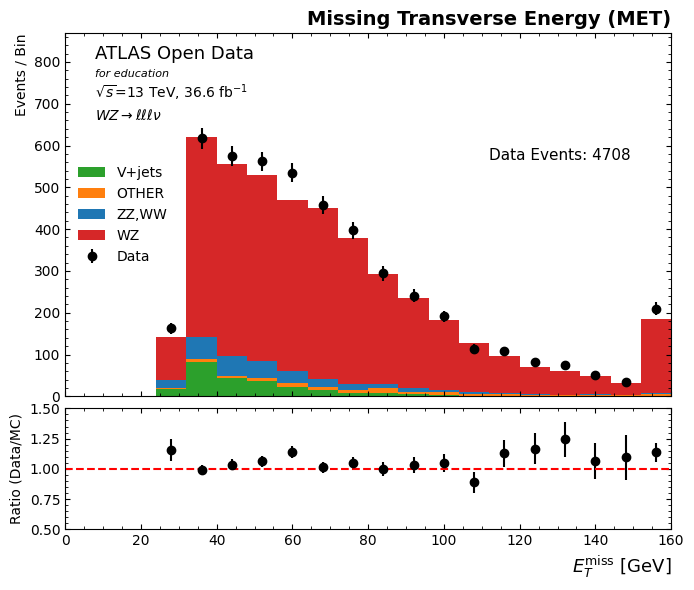

In [ ]:
# plot the Missing Transverse Energy (MET) distribution.
# 'np.hstack' is used to flatten the nested data arrays into a single continuous list for plotting.
# The parameters 0, 160, and 8 define the x-axis: starting at 0 GeV, ending at 160 GeV, with a bin width of 8 GeV.
plot_data(
    np.hstack(all_data['Data']['met']), 0, 160, 8, r"$E_T^{\mathrm{miss}}$ [GeV]", "Events / Bin", 
    "Missing Transverse Energy (MET)",
    
    # Pass the simulated signal and background arrays along with their respective physical weights
    np.hstack(all_data['Signal']['met']), np.hstack(all_data['Signal']['totalWeight']),
    np.hstack(all_data['Diboson']['met']), np.hstack(all_data['Diboson']['totalWeight']),
    np.hstack(all_data['Vjets']['met']), np.hstack(all_data['Vjets']['totalWeight']),
    np.hstack(all_data['other']['met']), np.hstack(all_data['other']['totalWeight'])
)

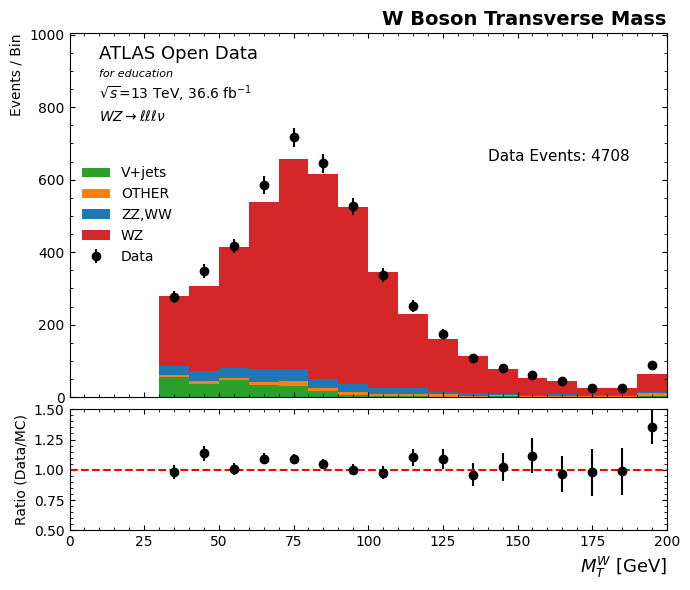

In [ ]:
# plot the reconstructed transverse mass of the W boson.
# the x-axis parameters (0, 200, 10) define the histogram range: 
# starting at 0 GeV, ending at 200 GeV, with a bin width of 10 GeV.
plot_data(
    np.hstack(all_data['Data']['wtmass']), 0, 200, 10, r"$M_T^W$ [GeV]", "Events / Bin",
    "W Boson Transverse Mass",
    
    # Pass the corresponding signal and background arrays for the W mass, along with their weights
    np.hstack(all_data['Signal']['wtmass']), np.hstack(all_data['Signal']['totalWeight']),
    np.hstack(all_data['Diboson']['wtmass']), np.hstack(all_data['Diboson']['totalWeight']),
    np.hstack(all_data['Vjets']['wtmass']), np.hstack(all_data['Vjets']['totalWeight']),
    np.hstack(all_data['other']['wtmass']), np.hstack(all_data['other']['totalWeight'])
)

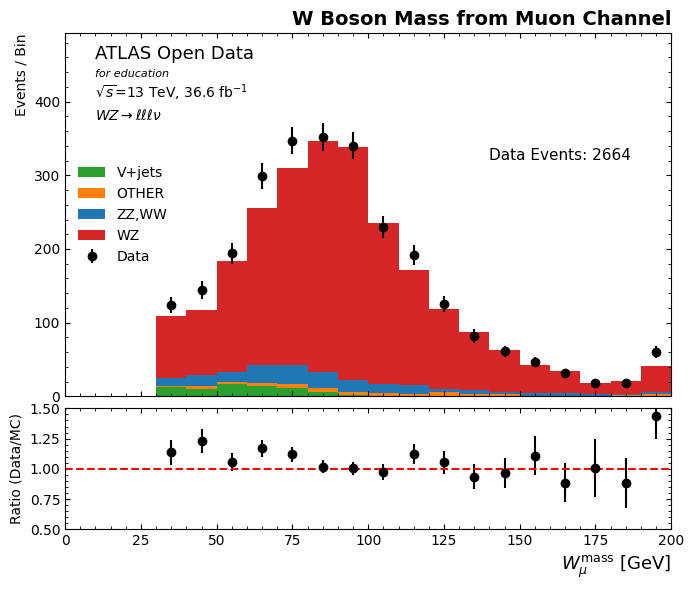

In [ ]:
# plot the reconstructed W boson transverse mass specifically for the muon decay channel.
# the histogram is set to display from 0 to 200 GeV, with a bin size of 10 GeV.
plot_data(
    np.hstack(all_data['Data']['wmuon']), 0, 200, 10, r"$W_μ^{\mathrm{mass}}$ [GeV]", "Events / Bin",
    "W Boson Mass from Muon Channel",
    
    # Pass the separated muon-channel arrays and their corresponding statistical weights
    np.hstack(all_data['Signal']['wmuon']), np.hstack(all_data['Signal']['totalWeight']),
    np.hstack(all_data['Diboson']['wmuon']), np.hstack(all_data['Diboson']['totalWeight']),
    np.hstack(all_data['Vjets']['wmuon']), np.hstack(all_data['Vjets']['totalWeight']),
    np.hstack(all_data['other']['wmuon']), np.hstack(all_data['other']['totalWeight'])
)

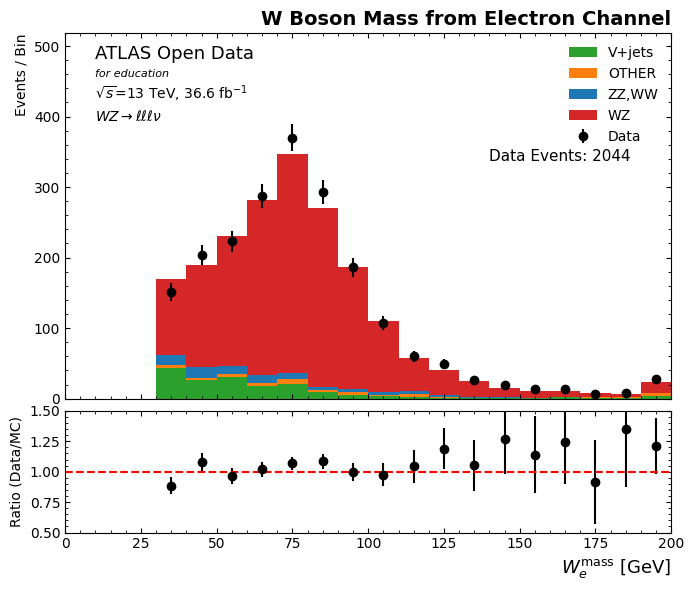

In [ ]:
# plot the reconstructed W boson transverse mass specifically for the electron decay channel.
# the histogram is set to display from 0 to 200 GeV, with a bin size of 10 GeV.
plot_data(
    np.hstack(all_data['Data']['welectron']), 0, 200, 10, r"$W_e^{\mathrm{mass}}$ [GeV]", "Events / Bin",
    "W Boson Mass from Electron Channel",
    
    # Pass the separated electron-channel arrays and their corresponding statistical weights
    np.hstack(all_data['Signal']['welectron']), np.hstack(all_data['Signal']['totalWeight']),
    np.hstack(all_data['Diboson']['welectron']), np.hstack(all_data['Diboson']['totalWeight']),
    np.hstack(all_data['Vjets']['welectron']), np.hstack(all_data['Vjets']['totalWeight']),
    np.hstack(all_data['other']['welectron']), np.hstack(all_data['other']['totalWeight'])
)

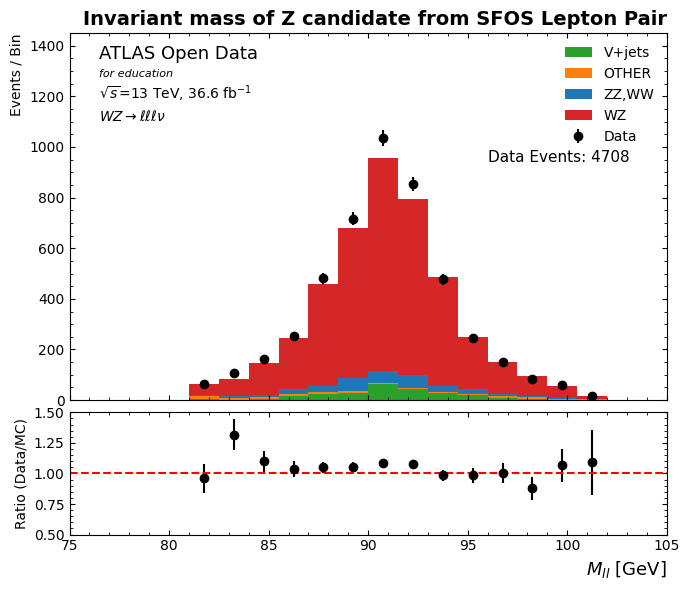

In [ ]:
# plot the invariant mass of the reconstructed Z boson from all selected SFOS lepton pairs.
# the histogram x-axis is configured to show the mass window from 75 GeV to 105 GeV,
# using a narrow bin width of 1.5 GeV to clearly resolve the Z boson peak around 91 GeV.
plot_data(
    np.hstack(all_data['Data']['zmass']), 75, 105, 1.5, r"$M_{ll}$ [GeV]", "Events / Bin",
    "Invariant mass of Z candidate from SFOS Lepton Pair",
    
    # Pass the corresponding Z mass arrays for signal and background along with their weights
    np.hstack(all_data['Signal']['zmass']), np.hstack(all_data['Signal']['totalWeight']),
    np.hstack(all_data['Diboson']['zmass']), np.hstack(all_data['Diboson']['totalWeight']),
    np.hstack(all_data['Vjets']['zmass']), np.hstack(all_data['Vjets']['totalWeight']),
    np.hstack(all_data['other']['zmass']), np.hstack(all_data['other']['totalWeight'])
)

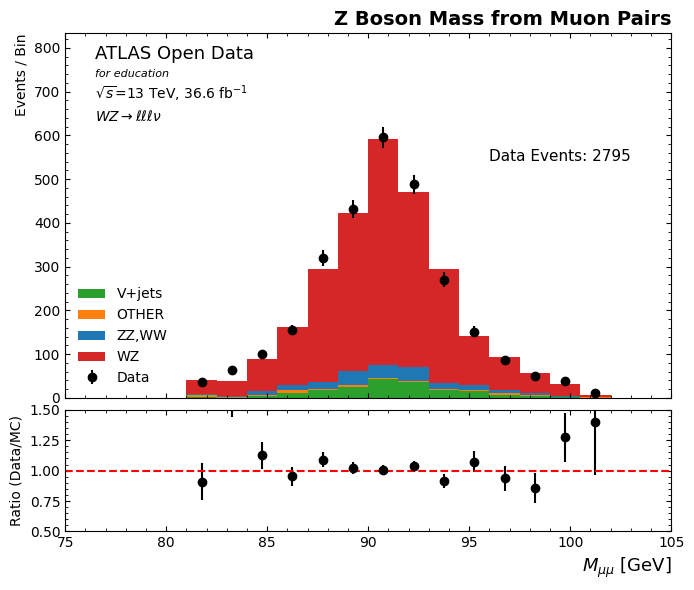

In [ ]:
# plot the invariant mass of the reconstructed Z boson specifically from the muon pair channel.
# the histogram is focused on the mass window from 75 GeV to 105 GeV, 
# with a bin width of 1.5 GeV to clearly display the Z boson peak.
plot_data(
    np.hstack(all_data['Data']['mumu_pair_mass']), 75, 105, 1.5, r"$M_{μμ}$ [GeV]", "Events / Bin",
    "Z Boson Mass from Muon Pairs",
    
    # Pass the separated muon-pair mass arrays for signal and background along with their corresponding weights
    np.hstack(all_data['Signal']['mumu_pair_mass']), np.hstack(all_data['Signal']['totalWeight']),
    np.hstack(all_data['Diboson']['mumu_pair_mass']), np.hstack(all_data['Diboson']['totalWeight']),
    np.hstack(all_data['Vjets']['mumu_pair_mass']), np.hstack(all_data['Vjets']['totalWeight']),
    np.hstack(all_data['other']['mumu_pair_mass']), np.hstack(all_data['other']['totalWeight'])
)

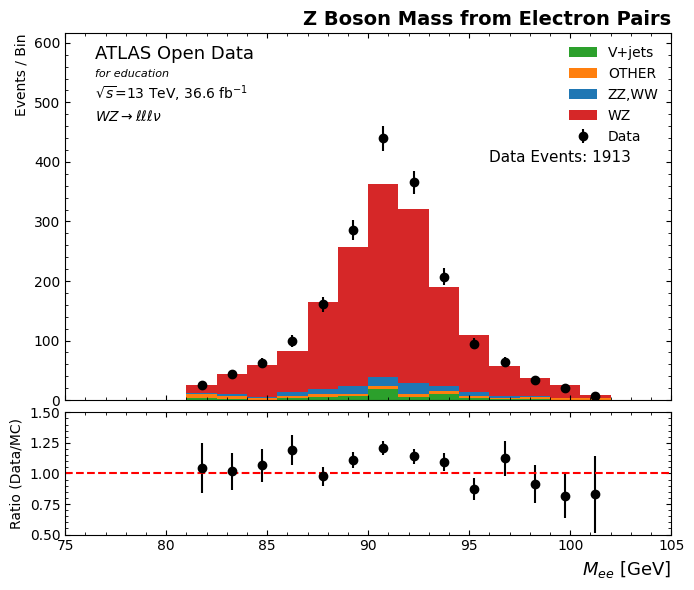

In [ ]:
# plot the invariant mass of the reconstructed Z boson specifically from the electron pair channel.
# the histogram is focused on the mass window from 75 GeV to 105 GeV, 
# with a bin width of 1.5 GeV to clearly display the Z boson peak.
plot_data(
    np.hstack(all_data['Data']['ee_pair_mass']), 75, 105, 1.5, r"$M_{ee}$ [GeV]", "Events / Bin",
    "Z Boson Mass from Electron Pairs",
    
    # Pass the separated electron-pair mass arrays for signal and background along with their corresponding weights
    np.hstack(all_data['Signal']['ee_pair_mass']), np.hstack(all_data['Signal']['totalWeight']),
    np.hstack(all_data['Diboson']['ee_pair_mass']), np.hstack(all_data['Diboson']['totalWeight']),
    np.hstack(all_data['Vjets']['ee_pair_mass']), np.hstack(all_data['Vjets']['totalWeight']),
    np.hstack(all_data['other']['ee_pair_mass']), np.hstack(all_data['other']['totalWeight'])
)

In [ ]:
'''import pandas as pd
import numpy as np

# the variables you want to give to the BDT
BDT_inputs = ['met', 'wtmass', 'zmass', 'welectron', 'wmuon'] 

df_list = []
for sample in ['Signal', 'Diboson', 'Vjets', 'other']:
    df_temp = pd.DataFrame()
    
    for var in BDT_inputs:
        df_temp[var] = np.hstack(all_data[sample][var])
        
    df_temp['totalWeight'] = np.hstack(all_data[sample]['totalWeight'])
    df_temp['sample_group'] = sample
    df_list.append(df_temp)

df_export = pd.concat(df_list, ignore_index=True)
df_export.to_csv('wz_machine_learning_data.csv', index=False)'''